In [1]:
import rasterio
import numpy as np
import geopandas as gpd
import pandas as pd
from rasterstats import zonal_stats
import seaborn as sns
import matplotlib.pyplot as plt
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import point_query
from rasterio.features import geometry_mask



In [2]:
# Define file path and canopy height threshold
file_path = r"C:\Users\bsf31\Documents\data\NM\meta\mod_nodata\canopy_height_hurley_2023.tif"
canopy_threshold = 2  # Minimum height in meters for a pixel to be considered canopy

In [3]:
src_file = r"C:\Users\bsf31\Documents\data\NM\meta\mod_nodata\canopy_height_hurley_2023.tif"
dst_file = r"C:\Users\bsf31\Documents\data\NM\meta\mod_nodata\canopy_height_hurley_2023_reprojected.tif"
dst_crs = 'EPSG:32612'  # UTM Zone 12N 



In [4]:
""" # Reproject the raster
with rasterio.open(src_file) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(dst_file, 'w', **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest)

print("Reprojection complete.") """

""" # Open the original raster
with rasterio.open(src_file) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )

    # Define output metadata
    kwargs = src.meta.copy()
    kwargs.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    # Create output file
    with rasterio.open(dst_file, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest  # Keep integer values intact
            ) """

' # Open the original raster\nwith rasterio.open(src_file) as src:\n    transform, width, height = calculate_default_transform(\n        src.crs, dst_crs, src.width, src.height, *src.bounds\n    )\n\n    # Define output metadata\n    kwargs = src.meta.copy()\n    kwargs.update({\n        "crs": dst_crs,\n        "transform": transform,\n        "width": width,\n        "height": height\n    })\n\n    # Create output file\n    with rasterio.open(dst_file, "w", **kwargs) as dst:\n        for i in range(1, src.count + 1):\n            reproject(\n                source=rasterio.band(src, i),\n                destination=rasterio.band(dst, i),\n                src_transform=src.transform,\n                src_crs=src.crs,\n                dst_transform=transform,\n                dst_crs=dst_crs,\n                resampling=Resampling.nearest  # Keep integer values intact\n            ) '

In [5]:
dst_file = r"C:\Users\bsf31\Documents\data\NM\meta\mod_nodata\canopy_height_hurley_utm12_1m.tif"


In [6]:


# Input and output CRS
src_crs = "EPSG:4326"    # Original WGS84
dst_crs = "EPSG:32612"   # UTM Zone 12
""" 
# Open original raster
with rasterio.open(src_file) as src:
    # Manually set 1m resolution
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds, resolution=(1, 1)  # Force 1m pixels
    )

    # Update metadata
    kwargs = src.meta.copy()
    kwargs.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    # Write reprojected raster with nearest-neighbor resampling
    with rasterio.open(dst_file, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest  # Keep integer values intact
            ) """

' \n# Open original raster\nwith rasterio.open(src_file) as src:\n    # Manually set 1m resolution\n    transform, width, height = calculate_default_transform(\n        src.crs, dst_crs, src.width, src.height, *src.bounds, resolution=(1, 1)  # Force 1m pixels\n    )\n\n    # Update metadata\n    kwargs = src.meta.copy()\n    kwargs.update({\n        "crs": dst_crs,\n        "transform": transform,\n        "width": width,\n        "height": height\n    })\n\n    # Write reprojected raster with nearest-neighbor resampling\n    with rasterio.open(dst_file, "w", **kwargs) as dst:\n        for i in range(1, src.count + 1):\n            reproject(\n                source=rasterio.band(src, i),\n                destination=rasterio.band(dst, i),\n                src_transform=src.transform,\n                src_crs=src.crs,\n                dst_transform=transform,\n                dst_crs=dst_crs,\n                resampling=Resampling.nearest  # Keep integer values intact\n            ) '

In [7]:
# Open the raster file
with rasterio.open(dst_file) as src:
    canopy_data = src.read(1)  # Read the first band
    pixel_area = src.res[0] * src.res[1]  # Area of each pixel in square meters

In [8]:
pixel_area

1.0

In [9]:
with rasterio.open(dst_file) as src:
    print("Resolution:", src.res)

Resolution: (1.0, 1.0)


## Overstory Statistics (Height > 2 meters) Entire Extent

In [10]:
# Conversion factor
meters_to_feet = 3.28084
square_meters_to_square_feet = 10.7639

In [11]:
canopy_threshold = 2  # Minimum height in meters for a pixel to be considered canopy

In [12]:
# Mask canopy pixels above threshold
canopy_mask = canopy_data > canopy_threshold

In [13]:
# Calculate the total area of canopy cover
canopy_area = np.sum(canopy_mask) * pixel_area  # Area in square meters
canopy_area_hectares = canopy_area / 10000  # Convert to hectares

In [14]:
canopy_area_sqft = canopy_area * square_meters_to_square_feet  # Convert to square feet


In [15]:
canopy_heights = canopy_data[canopy_mask]  # Extract heights where canopy exists

In [16]:
# Convert height statistics to feet
mean_height_ft = np.mean(canopy_heights) * meters_to_feet
median_height_ft = np.median(canopy_heights) * meters_to_feet
min_height_ft = np.min(canopy_heights) * meters_to_feet
max_height_ft = np.max(canopy_heights) * meters_to_feet
std_dev_height_ft= np.std(canopy_heights) * meters_to_feet

In [17]:
print(f"Total Canopy Area: {canopy_area_sqft:.2f} square feet")
print("Canopy Height Statistics:")
print(f"Mean Height: {mean_height_ft:.2f} feet")
print(f"Median Height: {median_height_ft:.2f} feet")
print(f"Minimum Height: {min_height_ft:.2f} feet")
print(f"Maximum Height: {max_height_ft:.2f} feet")
print(f"Standard Deviation of Height: {std_dev_height_ft:.2f} feet")

Total Canopy Area: 1012775.35 square feet
Canopy Height Statistics:
Mean Height: 17.75 feet
Median Height: 16.40 feet
Minimum Height: 9.84 feet
Maximum Height: 72.18 feet
Standard Deviation of Height: 8.08 feet


# Understory/Overstory Stats by Region

In [18]:
nm_path = r"C:\Users\bsf31\Documents\data\NM\nm_vector.gpkg"
gdf = gpd.read_file(nm_path, layer='hurley')

In [19]:
def canopy_area(arr, mask):
    valid_data = np.isfinite(arr) & (arr > canopy_threshold)
    return np.sum(valid_data) * pixel_area * square_meters_to_square_feet

In [20]:
# Calculate zonal statistics for each polygon in hurley_gdf
stats = zonal_stats(
    gdf,
    dst_file,
    stats=["mean", "median", "min", "max", "std"],
    add_stats={'area': canopy_area},
    prefix="canopy_"
)
zonal_df = pd.DataFrame(stats)
gdf = gdf.join(zonal_df)



In [21]:
stats

[{'canopy_min': 1.0,
  'canopy_max': 22.0,
  'canopy_mean': 3.507331010636894,
  'canopy_std': 2.7944665043795824,
  'canopy_median': 3.0,
  'canopy_area': np.float64(837043.9196)},
 {'canopy_min': 1.0,
  'canopy_max': 15.0,
  'canopy_mean': 3.0126874279123412,
  'canopy_std': 2.1674603017688816,
  'canopy_median': 2.0,
  'canopy_area': np.float64(174568.9302)}]

In [22]:
zonal_df

,canopy_min,canopy_max,canopy_mean,canopy_std,canopy_median,canopy_area
0,1.0,22.0,3.507331,2.794467,3.0,837043.9196
1,1.0,15.0,3.012687,2.167460,2.0,174568.9302


In [23]:
gdf

,place,area,geometry,canopy_min,canopy_max,canopy_mean,canopy_std,canopy_median,canopy_area
0,Hurley,1.874541e+06,"MULTIPOLYGON (((768777.31 3622536.394, 768747....",1.0,22.0,3.507331,2.794467,3.0,837043.9196
1,North Hurley,3.855291e+05,"MULTIPOLYGON (((768701.113 3624255.967, 768711...",1.0,15.0,3.012687,2.167460,2.0,174568.9302


In [24]:
# Convert height statistics to feet
gdf['canopy_mean'] *= meters_to_feet
gdf['canopy_median'] *= meters_to_feet
gdf['canopy_min'] *= meters_to_feet
gdf['canopy_max'] *= meters_to_feet
gdf['canopy_std'] *= meters_to_feet
gdf['canopy_area'] *= square_meters_to_square_feet

In [25]:
# Group by 'temp_name' to get aggregated canopy statistics
grouped_stats = gdf.groupby("place").agg({
    'canopy_mean':'mean',
    'canopy_median':'mean',
    'canopy_min': 'min',
    'canopy_max': 'max',
    'canopy_std': 'mean',
    'canopy_area': 'sum'
}).reset_index()

In [26]:
total_canopy_area = grouped_stats['canopy_area'].sum()

In [27]:
print(gdf)

          place          area  \
0        Hurley  1.874541e+06   
1  North Hurley  3.855291e+05   

                                            geometry  canopy_min  canopy_max  \
0  MULTIPOLYGON (((768777.31 3622536.394, 768747....     3.28084    72.17848   
1  MULTIPOLYGON (((768701.113 3624255.967, 768711...     3.28084    49.21260   

   canopy_mean  canopy_std  canopy_median   canopy_area  
0    11.506992    9.168197        9.84252  9.009857e+06  
1     9.884145    7.111090        6.56168  1.879043e+06  


In [28]:
gdf.columns

Index(['place', 'area', 'geometry', 'canopy_min', 'canopy_max', 'canopy_mean',
       'canopy_std', 'canopy_median', 'canopy_area'],
      dtype='object')

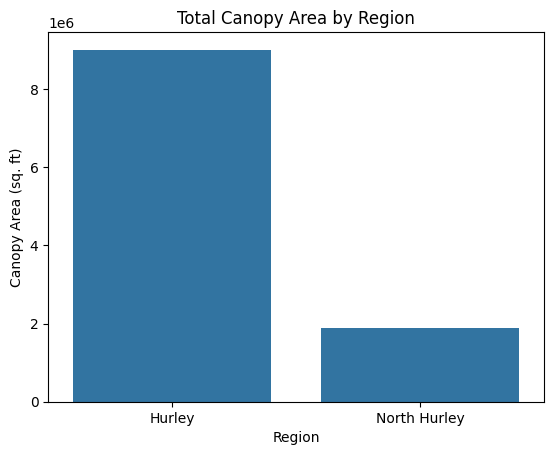

In [29]:
sns.barplot(x='place', y='canopy_area', data=grouped_stats)
plt.title('Total Canopy Area by Region')
plt.xlabel('Region')
plt.ylabel('Canopy Area (sq. ft)')
plt.show()

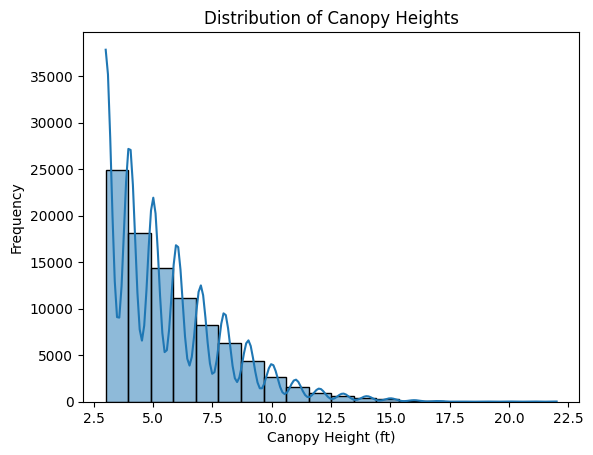

In [30]:
sns.histplot(canopy_heights, bins=20, kde=True)
plt.title('Distribution of Canopy Heights')
plt.xlabel('Canopy Height (ft)')
plt.ylabel('Frequency')
plt.show()


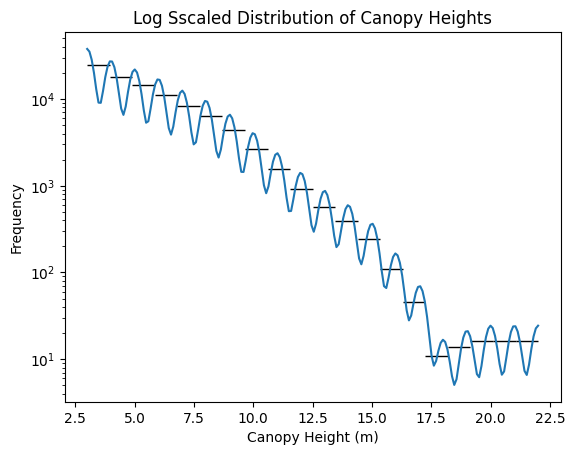

In [31]:
sns.histplot(canopy_heights, bins=20, kde=True, log_scale=(False, True))
plt.title('Log Sscaled Distribution of Canopy Heights')
plt.xlabel('Canopy Height (m)')
plt.ylabel('Frequency')
plt.show()

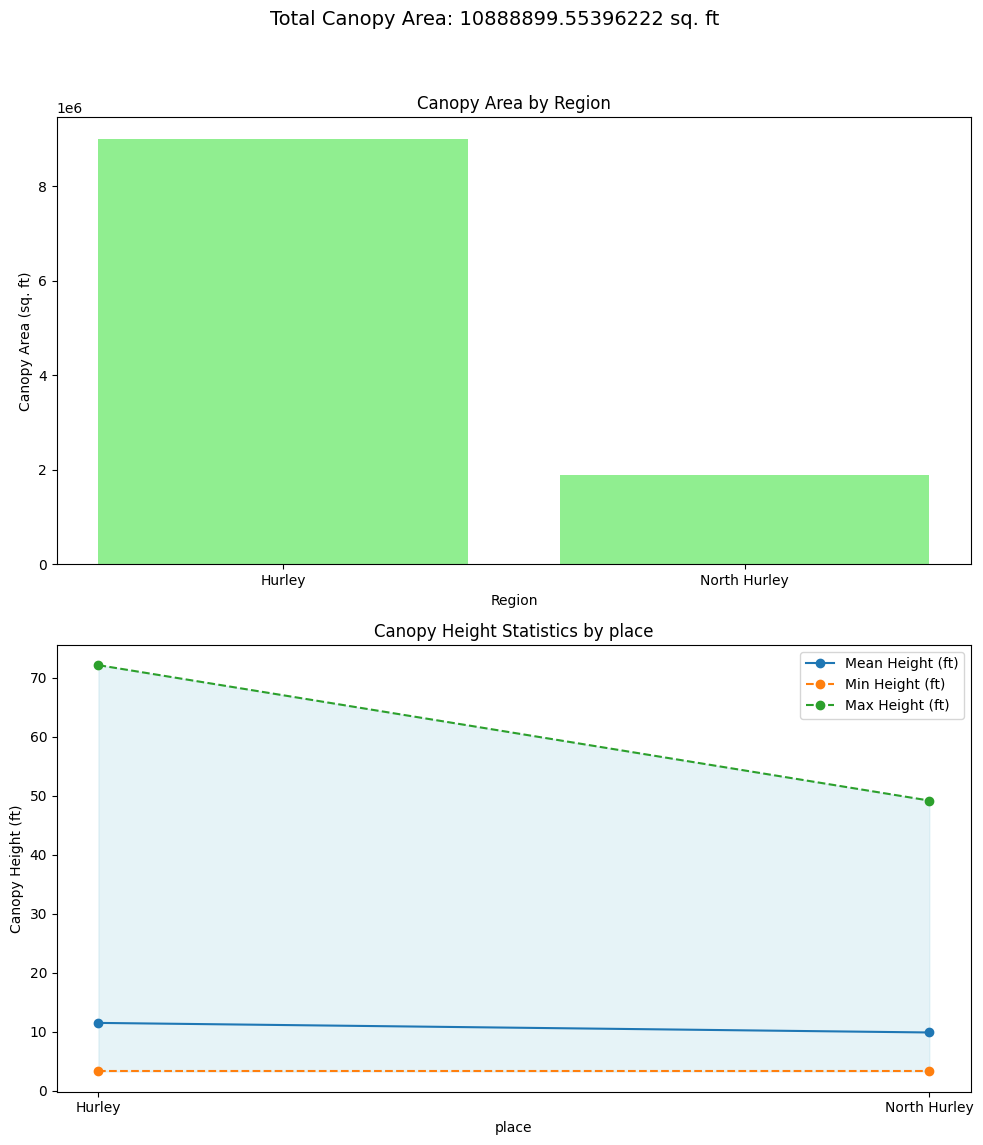

In [32]:
# Plotting
fig, ax = plt.subplots(2, 1, figsize=(10, 12))

# Bar chart for canopy area by place
ax[0].bar(gdf["place"], gdf["canopy_area"], color='lightgreen')
ax[0].set_title("Canopy Area by Region")
ax[0].set_ylabel("Canopy Area (sq. ft)")
ax[0].set_xlabel("Region")
# Line plot for canopy height stats by place
ax[1].plot(gdf["place"], gdf["canopy_mean"], marker='o', label='Mean Height (ft)')
ax[1].plot(gdf["place"], gdf["canopy_min"], marker='o', linestyle='--', label='Min Height (ft)')
ax[1].plot(gdf["place"], gdf["canopy_max"], marker='o', linestyle='--', label='Max Height (ft)')
ax[1].fill_between(gdf["place"], gdf["canopy_min"], gdf["canopy_max"], color='lightblue', alpha=0.3)
ax[1].set_title("Canopy Height Statistics by place")
ax[1].set_ylabel("Canopy Height (ft)")
ax[1].set_xlabel("place")
ax[1].legend()

# Display the total canopy area on the plot
fig.suptitle(f"Total Canopy Area: {total_canopy_area} sq. ft", fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [33]:
# %% Calculate Understory and Overstory Stats for Each Polygon
def calculate_region_understory_overstory_stats(geometry, canopy_raster, mask, transform):
    """Calculate understory and overstory stats for a specific polygon region."""
    # Mask the raster by the geometry
    region_mask = rasterio.features.geometry_mask(
        [geometry], transform=transform, invert=True, out_shape=canopy_raster.shape)
    
    combined_mask = region_mask & mask  # Combine with canopy mask
    
    # Separate understory and overstory
    understory_mask = (canopy_raster > 1) & (canopy_raster <= 3) & combined_mask
    overstory_mask = (canopy_raster > 3) & combined_mask
    
    # Calculate areas
    understory_area = np.sum(understory_mask) * pixel_area
    overstory_area = np.sum(overstory_mask) * pixel_area
    
    # Percentages (relative to the region area)
    region_area = np.sum(region_mask) * pixel_area
    understory_percent = (understory_area / region_area) * 100 if region_area > 0 else 0
    overstory_percent = (overstory_area / region_area) * 100 if region_area > 0 else 0
    
    return {
        'understory_area': understory_area,
        'understory_percent': understory_percent,
        'overstory_area': overstory_area,
        'overstory_percent': overstory_percent
    }

In [34]:
# %% Apply Stats Calculation to Each Region in the GeoDataFrame
with rasterio.open(dst_file) as src:
    canopy_data = src.read(1)
    transform = src.transform

    stats = []
    for _, row in gdf.iterrows():
        stats.append(calculate_region_understory_overstory_stats(
            row.geometry, canopy_data, canopy_mask, transform))

In [35]:

# Convert stats to a DataFrame and merge with GeoDataFrame
stats_df = pd.DataFrame(stats)


In [36]:
stats_df

,understory_area,understory_percent,overstory_area,overstory_percent
0,19872.0,1.059046,57892.0,3.085261
1,4967.0,1.287174,11251.0,2.915643


In [37]:
gdf = pd.concat([gdf, stats_df], axis=1)
gdf

,place,area,geometry,canopy_min,canopy_max,canopy_mean,canopy_std,canopy_median,canopy_area,understory_area,understory_percent,overstory_area,overstory_percent
0,Hurley,1.874541e+06,"MULTIPOLYGON (((768777.31 3622536.394, 768747....",3.28084,72.17848,11.506992,9.168197,9.84252,9.009857e+06,19872.0,1.059046,57892.0,3.085261
1,North Hurley,3.855291e+05,"MULTIPOLYGON (((768701.113 3624255.967, 768711...",3.28084,49.21260,9.884145,7.111090,6.56168,1.879043e+06,4967.0,1.287174,11251.0,2.915643


In [38]:
# %% Recalculate Canopy Cover Percent
gdf['canopy_cover_percent'] = (
    (gdf['understory_area'] + gdf['overstory_area']) / gdf['area']) * 100

# %% Group by Region and Summarize
summary_stats = gdf.groupby('place').agg({
    'canopy_cover_percent': 'mean',
    'understory_area': 'sum',
    'overstory_area': 'sum',
    'understory_percent': 'mean',
    'overstory_percent': 'mean'
}).reset_index()

# %% Display Results
print(summary_stats)


          place  canopy_cover_percent  understory_area  overstory_area  \
0        Hurley              4.148429          19872.0         57892.0   
1  North Hurley              4.206686           4967.0         11251.0   

   understory_percent  overstory_percent  
0            1.059046           3.085261  
1            1.287174           2.915643  


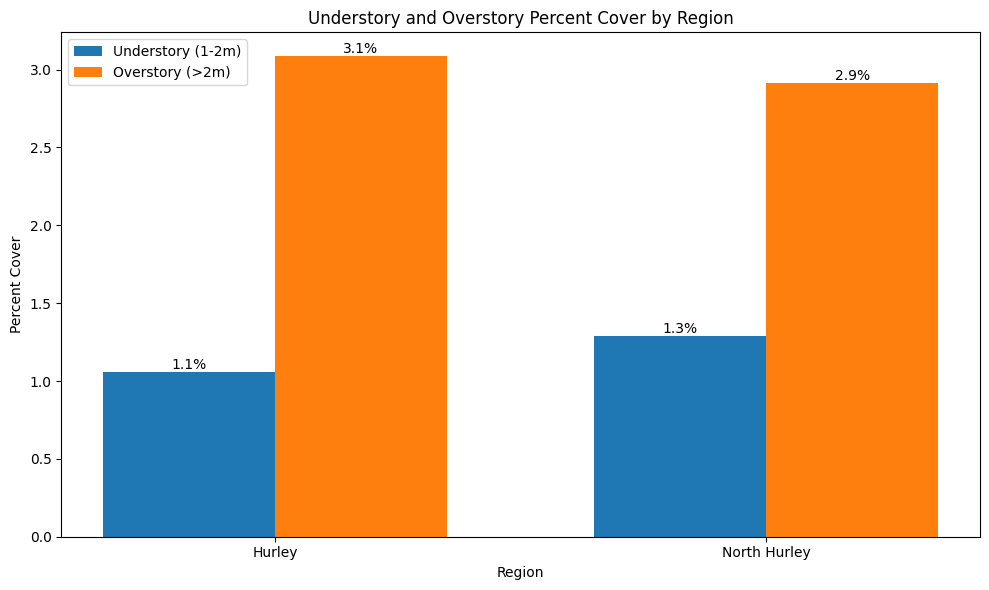

In [39]:

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(summary_stats))

# Create the bars
understory_bars = ax.bar(index, summary_stats['understory_percent'], bar_width, label='Understory (1-2m)')
overstory_bars = ax.bar(index + bar_width, summary_stats['overstory_percent'], bar_width, label='Overstory (>2m)')

# Add annotations
for bar in understory_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height,  # Position text at center of the bar
        f"{height:.1f}%",  # Format the text
        ha='center', va='bottom', fontsize=10  # Alignment and font size
    )

for bar in overstory_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height,
        f"{height:.1f}%",
        ha='center', va='bottom', fontsize=10
    )

# Set plot labels and title
ax.set_title('Understory and Overstory Percent Cover by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Percent Cover')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(summary_stats['place'])
ax.legend()

plt.tight_layout()
plt.show()


In [40]:
overstory_markdown = f"""
## Overstory Statistics (Height > 2 meters)

**Total Canopy Area:** {canopy_area_sqft:.2f} square feet  

### **Canopy Height Statistics**
- **Mean Height:** {mean_height_ft:.2f} feet  
- **Median Height:** {median_height_ft:.2f} feet  
- **Minimum Height:** {min_height_ft:.2f} feet  
- **Maximum Height:** {max_height_ft:.2f} feet  
- **Standard Deviation of Height:** {std_dev_height_ft:.2f} feet  
"""

print(overstory_markdown)



## Overstory Statistics (Height > 2 meters)

**Total Canopy Area:** 1012775.35 square feet  

### **Canopy Height Statistics**
- **Mean Height:** 17.75 feet  
- **Median Height:** 16.40 feet  
- **Minimum Height:** 9.84 feet  
- **Maximum Height:** 72.18 feet  
- **Standard Deviation of Height:** 8.08 feet  



In [41]:
# Generate Overstory Statistics Markdown Table
overstory_markdown = f"""
## Overstory Statistics (Height > 2 meters)

| Total Canopy Area (sqft) | Mean Height (ft) | Median Height (ft) | Min Height (ft) | Max Height (ft) | Std Dev Height (ft) |
|-------------------------|-----------------|-----------------|-----------------|-----------------|------------------|
| {canopy_area_sqft:.2f} | {mean_height_ft:.2f} | {median_height_ft:.2f} | {min_height_ft:.2f} | {max_height_ft:.2f} | {std_dev_height_ft:.2f} |
"""

print(overstory_markdown)



## Overstory Statistics (Height > 2 meters)

| Total Canopy Area (sqft) | Mean Height (ft) | Median Height (ft) | Min Height (ft) | Max Height (ft) | Std Dev Height (ft) |
|-------------------------|-----------------|-----------------|-----------------|-----------------|------------------|
| 1012775.35 | 17.75 | 16.40 | 9.84 | 72.18 | 8.08 |



In [42]:
gdf

,place,area,geometry,canopy_min,canopy_max,canopy_mean,canopy_std,canopy_median,canopy_area,understory_area,understory_percent,overstory_area,overstory_percent,canopy_cover_percent
0,Hurley,1.874541e+06,"MULTIPOLYGON (((768777.31 3622536.394, 768747....",3.28084,72.17848,11.506992,9.168197,9.84252,9.009857e+06,19872.0,1.059046,57892.0,3.085261,4.148429
1,North Hurley,3.855291e+05,"MULTIPOLYGON (((768701.113 3624255.967, 768711...",3.28084,49.21260,9.884145,7.111090,6.56168,1.879043e+06,4967.0,1.287174,11251.0,2.915643,4.206686


In [43]:
# Generate Study Area Statistics Markdown
study_area_markdown = f"""
## Study Area Canopy Statistics

| Total Area (sqft) | Canopy Min Height (ft) | Canopy Max Height (ft) | Mean Height (ft) | Std Dev Height (ft) | Total Canopy Area (sqft) |
|------------------|----------------------|----------------------|----------------|-----------------|----------------------|
| {gdf['area'].sum():,.0f} | {gdf['canopy_min'].min():.2f} | {gdf['canopy_max'].max():.2f} | {gdf['canopy_mean'].mean():.2f} | {gdf['canopy_std'].mean():.2f} | {gdf['canopy_area'].sum():,.0f} |
"""

print(study_area_markdown)



## Study Area Canopy Statistics

| Total Area (sqft) | Canopy Min Height (ft) | Canopy Max Height (ft) | Mean Height (ft) | Std Dev Height (ft) | Total Canopy Area (sqft) |
|------------------|----------------------|----------------------|----------------|-----------------|----------------------|
| 2,260,070 | 3.28 | 72.18 | 10.70 | 8.14 | 10,888,900 |



In [44]:
overstory_understory_markdown = "## Overstory & Understory Statistics by Region\n\n"
overstory_understory_markdown += "| Region | Canopy Cover (%) | Understory Area (sqft) | Overstory Area (sqft) | Understory (%) | Overstory (%) |\n"
overstory_understory_markdown += "|--------|-----------------|------------------------|-----------------------|---------------|--------------|\n"

for _, row in gdf.iterrows():
    overstory_understory_markdown += f"| {row['place']} | {row['canopy_cover_percent']:.2f} | {row['understory_area']:.2f} | {row['overstory_area']:.2f} | {row['understory_percent']:.2f} | {row['overstory_percent']:.2f} |\n"

print(overstory_understory_markdown)


## Overstory & Understory Statistics by Region

| Region | Canopy Cover (%) | Understory Area (sqft) | Overstory Area (sqft) | Understory (%) | Overstory (%) |
|--------|-----------------|------------------------|-----------------------|---------------|--------------|
| Hurley | 4.15 | 19872.00 | 57892.00 | 1.06 | 3.09 |
| North Hurley | 4.21 | 4967.00 | 11251.00 | 1.29 | 2.92 |



## Overstory & Understory Statistics by Region

| Region | Canopy Cover (%) | Understory Area (sqft) | Overstory Area (sqft) | Understory (%) | Overstory (%) |
|--------|-----------------|------------------------|-----------------------|---------------|--------------|
| Lordsburg | 0.36 | 6384.00 | 10536.00 | 0.13 | 0.22 |

In [46]:
gdf.to_file(nm_path, layer='hurley_tc_ft', driver='GPKG')